In [2]:
import os
os.chdir('/app')

In [3]:
!python3 tests/fba.py
!python3 tests/full_dimensional.py
!python3 tests/max_ball.py
!python3 tests/scaling.py
!python3 tests/rounding.py
!python3 tests/sampling.py

...
----------------------------------------------------------------------
Ran 4 tests in 0.700s

OK
..
----------------------------------------------------------------------
Ran 3 tests in 1.506s

OK
.
----------------------------------------------------------------------
Ran 1 test in 0.002s

OK
..
----------------------------------------------------------------------
Ran 3 tests in 0.570s

OK
..Failed to compute max inscribed ball, trying to use lpsolve
...
----------------------------------------------------------------------
Ran 5 tests in 2.324s

OK
phase 1: number of correlated samples = 500, effective sample size = 24, ratio of the maximum singilar value over the minimum singular value = 1099.5
phase 2: number of correlated samples = 500, effective sample size = 8, ratio of the maximum singilar value over the minimum singular value = 364.142
phase 3: number of correlated samples = 500, effective sample size = 4, ratio of the maximum singilar value over the minimum singular valu

In [26]:
from dingo import MetabolicNetwork
import numpy as np

In [6]:
os.getcwd()

'/app'

In [7]:
model = MetabolicNetwork.from_sbml('./../workspaces/mitocore-smoment-model/smoment/flux_sampling/Mitocore_aligned_to_Human1_sampling_model.xml')

In [9]:
fba_output = model.fba()
fba_output

(array([-0.00000000e+00, -1.15131429e-01, -0.00000000e+00, ...,
         4.79075518e-05,  0.00000000e+00,  1.94898952e-04]),
 2.194453033063441)

In [10]:
from dingo import PolytopeSampler
sampler = PolytopeSampler(model)

In [14]:
steady_states = sampler.generate_steady_states(ess = 1000, psrf = True, parallel_mmcs=True, num_threads=8)

phase 1: number of correlated samples = 13600, effective sample size = 101, ratio of the maximum singilar value over the minimum singular value = 18185.5
phase 2: number of correlated samples = 13600, effective sample size = 101, ratio of the maximum singilar value over the minimum singular value = 5317.42
phase 3: number of correlated samples = 13600, effective sample size = 95, ratio of the maximum singilar value over the minimum singular value = 4339.16
phase 4: number of correlated samples = 13600, effective sample size = 90, ratio of the maximum singilar value over the minimum singular value = 1886.59
phase 5: number of correlated samples = 13600, effective sample size = 91, ratio of the maximum singilar value over the minimum singular value = 4625.62
phase 6: number of correlated samples = 13600, effective sample size = 93, ratio of the maximum singilar value over the minimum singular value = 29104.1
phase 7: number of correlated samples = 13600, effective sample size = 95, ratio

[4]maximum marginal PSRF: 1.05478


phase 11: number of correlated samples = 8000, effective sample size = 51
[4]total ess 1010: number of correlated samples = 144000




In [50]:
model.reactions.index('EX_lac_L_e')

39

In [70]:
test = np.array([value for value in steady_states[39] if value > -100.0 and value < 100.0])
len(test)

10000

In [52]:
fva_output = model.fva()

In [53]:
fva_output[1][39]

57.2513488456896

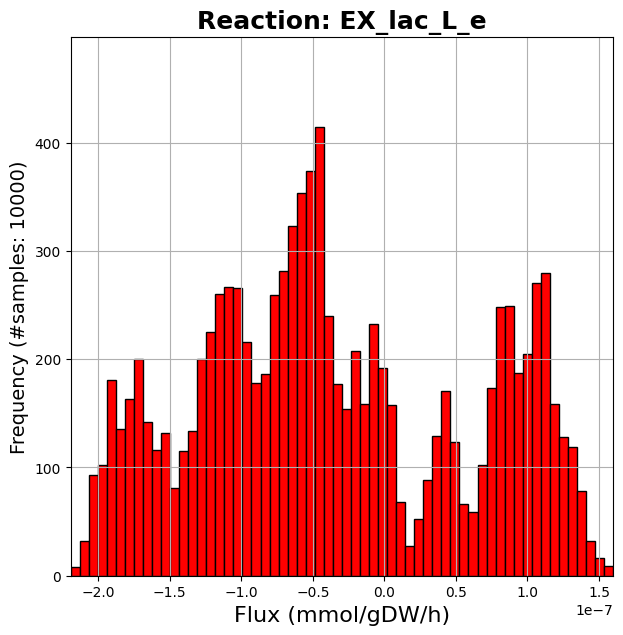

In [71]:
from dingo import plot_histogram

reactions = model.reactions
plot_histogram(
        test,  # here we set which reaction's flux we need to get 
        reactions[39],      # here we provide the name of the reaction
        n_bins = 60,
)

In [69]:
steady_states = sampler.generate_steady_states_no_multiphase(method='cdhr', n=10000, burn_in=5000, thinning=1000)